In [1]:
import numpy as np
import pandas as pd
from IPython.display import display, Math
from sympy import symbols, simplify, factorial, expand


# Інтерполювання Лагранжа/Ньютана (9, 10 лекції)

Обрання вузлів інтерполювання за Чебишовим

In [ ]:
variant = 4
a = -variant           # початок відрізка
b = variant + 1        # кінець відрізка
n = 5                  # кількість вузлів (n штук)

# Формула з твого слайду: x_i = -cos((2i + 1) * pi / (2n)), i = 0..n-1
i = np.arange(n)
x_cheb_correct = -np.cos((2 * i + 1) * np.pi / (2 * n))

# Масштабування на [a, b]
t_i = (a + b) / 2 + (b - a) / 2 * x_cheb_correct

# Створення таблиці вузлів
chebyshev_nodes = pd.DataFrame({
    "i": i,
    "x_i (на [-1,1])": np.round(x_cheb_correct, 4),
    "t_i (на [{},{}])".format(a, b): np.round(t_i, 4)
})
chebyshev_nodes

,i,"x_i (на [-1,1])","t_i (на [-4,5])"
0,0,-0.9511,-3.7798
1,1,-0.5878,-2.1450
2,2,-0.0000,0.5000
3,3,0.5878,3.1450
4,4,0.9511,4.7798


In [3]:
Y = [1, 3, 4, 2, 0]
X = t_i

Інтерполювання Лагранжа

In [4]:
L_tex = r"L(x) = "

for i, y in enumerate(Y):
    y_rounded = round(y, 4)
    x_i = round(X[i], 4)
    numerator = ""
    denominator = ""
    for j, xj in enumerate(X):
        if j != i:
            xj_rounded = round(xj, 4)
            numerator += f"(x - {xj_rounded})"
            denominator += f"({round(x_i - xj_rounded, 4)})"
    term = f"{y_rounded} \\cdot \\frac{{{numerator}}}{{{denominator}}}"
    if i != 0:
        L_tex += " + "
    L_tex += term

display(Math(L_tex))


<IPython.core.display.Math object>

Інтерполювання Ньютона

In [37]:
X = [3,5, 8]
Y = [4, 5, 6]


In [38]:
table = [Y.copy()]  # перший рядок — значення функції

k = len(X)

for level in range(1, k):  # будуємо рівні 1, 2, ...
    prev = table[-1]       # попередній рівень
    current = []
    for i in range(k - level):
        val = round((prev[i+1] - prev[i]) / (X[i+level] - X[i]), 4)
        current.append(val)
    table.append(current)
print(table)

[[4, 5, 6], [0.5, 0.3333], [-0.0333]]


In [39]:
# Формування табличної структури для виводу
columns = ['x', 'f(x)'] + [f"f({','.join(['xᵢ']*(i+2))})" for i in range(k - 1)]
data = []

for i in range(k):
    row = [X[i]]
    for level in range(k):
        if i < len(table[level]):
            row.append(table[level][i])
        else:
            row.append('-')
    data.append(row)

df = pd.DataFrame(data, columns=columns)
df

,x,f(x),"f(xᵢ,xᵢ)","f(xᵢ,xᵢ,xᵢ)"
0,3,4,0.5,-0.0333
1,5,5,0.3333,-
2,8,6,-,-


In [40]:
coefs = data[0][1:]

# Символьная переменная
x = symbols('x')

# Строим полином Ньютона
polynomial = coefs[0]
term = 1  # начальный множитель

for i in range(1, len(coefs)):
    term *= (x - X[i-1])
    polynomial += coefs[i] * term

print(polynomial)


0.5*x - 0.0333*(x - 5)*(x - 3) + 2.5


In [42]:
x=0
0.5*x - 0.0333*(x - 5)*(x - 3) + 2.5

2.0004999999999997

# Перша та друга інтерполяційна формули Ньютона

In [9]:
X = [19, 24, 29, 34, 39]  # кути в градусах
X_rad = np.radians(X)     # переводимо в радіани
Y = [np.sin(x) for x in X_rad]

In [29]:
Y = [4, 5, 6]
X = [3, 5, 8]

In [30]:
table = [Y.copy()]  # перший рядок — значення функції

k = len(X)

for level in range(1, k):  # будуємо рівні 1, 2, ...
    prev = table[-1]       # попередній рівень
    current = []
    for i in range(k - level):
        val = round((prev[i+1] - prev[i]), 6)
        current.append(val)
    table.append(current)

In [31]:
# Формування табличної структури для виводу
columns = ['x', 'y'] + [f"delta^{i}y" for i in range(1, k)]
data = []

for i in range(k):
    row = [X[i]]
    for level in range(k):
        if i < len(table[level]):
            row.append(table[level][i])
        else:
            row.append('-')
    data.append(row)

df = pd.DataFrame(data, columns=columns)
df

,x,y,delta^1y,delta^2y
0,3,4,1,0
1,5,5,1,-
2,8,6,-,-


In [32]:
np.set_printoptions(suppress=True, precision=10)

In [33]:
data = np.array(data)
first_numbers = data[:, 1:][0]
first_numbers = first_numbers.astype(float)
first_numbers

array([4., 1., 0.])

## Перша інтерполіційна Ньютона

In [36]:
h = X[1] - X[0]
x = symbols('x')
q = (x - X[0]) / h
q

x/2 - 3/2

In [35]:
# Побудова полінома Ньютона
P = 0
for k in range(3):  # до 3-го порядку включно
    term = first_numbers[k]
    for i in range(k):
        term *= (q - i)
    term /= factorial(k)
    P += term

# Вивід
P = simplify(P)
print(P)

0.5*x + 2.5


In [16]:
x = 14
0.01664*x + (0.0018 - 0.00012*x)*(x/5 - 5)*(x/5 - 4)/6 + (0.0078 - 0.00052*x)*(x/5 - 4)/2 + 0.00919999999999999

0.24190079999999994

Друга інтерполяційна формула Ньютона

In [17]:
last_numbers = []

for col in range(data.shape[1]):
    column_values = data[:, col]
    # Фільтруємо тільки числові значення
    numeric_values = [v for v in column_values if v.replace('.', '', 1).replace('-', '', 1).isdigit()]
    if numeric_values:
        last_numbers.append(float(numeric_values[-1]))
    else:
        last_numbers.append(None)  # або np.nan
last_numbers = last_numbers[1:]
last_numbers

[0.6293203910498374, 0.070127, -0.004256, -0.000566, None]

In [18]:
h = X[1] - X[0]
x = symbols('x')
q = (x - X[-1]) / h
q

x/5 - 39/5

In [19]:
# Побудова полінома Ньютона
P = 0
for k in range(4):  # до 3-го порядку включно
    term = last_numbers[k]
    for i in range(k):
        term *= (q + i)
    term /= factorial(k)
    P += term

# Вивід
# P = simplify(P)
print(P)

0.0140254*x + (0.0044148 - 0.0001132*x)*(x/5 - 34/5)*(x/5 - 29/5)/6 + (0.0331968 - 0.0008512*x)*(x/5 - 34/5)/2 + 0.0823297910498374


скопировать формулу надо

In [20]:
x = 56
0.01064*x + (0.0033 - 6.0e-5*x)*(x/5 - 10)*(x/5 - 9)/6 + (0.0627 - 0.00114*x)*(x/5 - 10)/2 + 0.234

0.8291296

# Метод квадратного кореня (4 лекція)

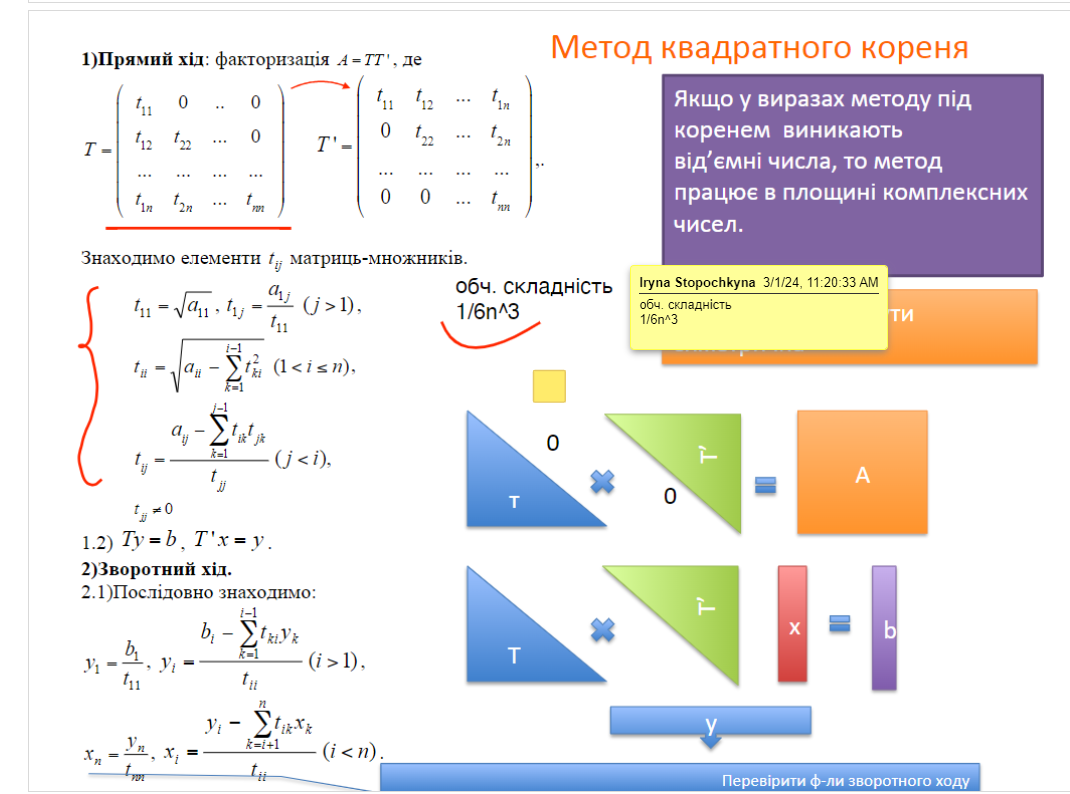